In [20]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# 1.load data:
df_all = pd.read_csv("launch_modeling_base_with_weather.csv")

base_df = df_all.copy()
weather_df = df_all[df_all["weather_matched"] == True].copy()

print(df_all["data_split"].value_counts())
print("All data:", base_df.shape)
print("Weather matched:", weather_df.shape)

# 2.LR helper:
def run_logistic_regression(df, feature_cols, target_col="is_success", model_name="Logistic Regression"):
    df_model = df[feature_cols + [target_col, "data_split"]].copy()
    df_model = df_model.dropna(subset=[target_col, "data_split"])
    
    train_df = df_model[df_model["data_split"] == "train"].copy()
    val_df   = df_model[df_model["data_split"] == "validation"].copy()
    test_df  = df_model[df_model["data_split"] == "test"].copy()
    
    X_train = train_df[feature_cols]
    y_train = train_df[target_col].astype(int)
    
    X_val = val_df[feature_cols]
    y_val = val_df[target_col].astype(int)
    
    X_test = test_df[feature_cols]
    y_test = test_df[target_col].astype(int)
    
    numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_features = X_train.select_dtypes(include=["object", "bool"]).columns.tolist()
    
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )
    
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ])
    
    model.fit(X_train, y_train)
    
    def evaluate(split_name, X, y):
        y_pred = model.predict(X)
        y_prob = model.predict_proba(X)[:, 1]
        
        print(f"\n{model_name} - {split_name}")
        print("Size:", X.shape[0])
        print("Accuracy:", accuracy_score(y, y_pred))
        print("ROC AUC:", roc_auc_score(y, y_prob))
        print("Confusion Matrix:")
        print(confusion_matrix(y, y_pred))
        print("Classification Report:")
        print(classification_report(y, y_pred))
    
    evaluate("Validation", X_val, y_val)
    evaluate("Test", X_test, y_test)
    
    return model


# 3.baseline model: no weather
base_features = [
    "launch_year",
    "launch_month",
    "launch_quarter",
    "launch_dayofweek",
    "launch_hour_utc",
    "is_suborbital",
    
    "Rocket Organisation",
    "Rocket Name",
    "rocket_family",
    "company_country",
    "company_ownership",
    "Country",
    "facility_group",
    
    "Rocket Price",
    "Rocket Payload to LEO",
    "payload_count",
    "mission_mass",
    "config_liftoff_thrust",
    "config_payload_leo",
    "config_payload_gto",
    "config_stages",
    "config_strap_ons",
    "config_rocket_height",
    "config_fairing_diameter",
    "config_fairing_height",
    "family_success_rate_pct"
]

base_features = [col for col in base_features if col in base_df.columns]

logit_base = run_logistic_regression(
    base_df,
    base_features,
    model_name="Logistic Regression - No Weather"
)


#4.weather model: with weather
weather_features = [
    "HourlyDryBulbTemperature",
    "HourlyDewPointTemperature",
    "HourlySeaLevelPressure",
    "HourlyWindSpeed",
    "HourlyWindDirection",
    "HourlyStationPressure",
    "HourlyRelativeHumidity",
    "HourlyPrecipitation",
    "HourlyVisibility",
    "HourlyWindGustSpeed",
    "HourlyWetBulbTemperature",
    
    "present_weather_rain_flag",
    "present_weather_fog_flag",
    "present_weather_thunder_flag",
    "cloud_cover_broken_or_overcast_flag",
    "short_duration_precip_max",
    "weather_time_diff_minutes"
]

weather_features = [col for col in weather_features if col in weather_df.columns]

logit_weather = run_logistic_regression(
    weather_df,
    base_features + weather_features,
    model_name="Logistic Regression - With Weather"
)

data_split
train         4317
test           926
validation     925
Name: count, dtype: int64
All data: (6168, 88)
Weather matched: (3367, 88)

Logistic Regression - No Weather - Validation
Size: 925
Accuracy: 0.8572972972972973
ROC AUC: 0.7272212790039615
Confusion Matrix:
[[ 20  37]
 [ 95 773]]
Classification Report:
              precision    recall  f1-score   support

           0       0.17      0.35      0.23        57
           1       0.95      0.89      0.92       868

    accuracy                           0.86       925
   macro avg       0.56      0.62      0.58       925
weighted avg       0.91      0.86      0.88       925


Logistic Regression - No Weather - Test
Size: 926
Accuracy: 0.9319654427645788
ROC AUC: 0.6927251852624987
Confusion Matrix:
[[ 17  38]
 [ 25 846]]
Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.31      0.35        55
           1       0.96      0.97      0.96       871

    accuracy    

In [21]:
#same dataset comparison
df = weather_df.copy()  

#model A: no weather
logit_no_weather_same = run_logistic_regression(
    df,
    base_features,
    model_name="Same Data - No Weather"
)

#model B: with weather
logit_with_weather_same = run_logistic_regression(
    df,
    base_features + weather_features,
    model_name="Same Data - With Weather"
)


Same Data - No Weather - Validation
Size: 363
Accuracy: 0.8870523415977961
ROC AUC: 0.6562117503059975
Confusion Matrix:
[[  2  17]
 [ 24 320]]
Classification Report:
              precision    recall  f1-score   support

           0       0.08      0.11      0.09        19
           1       0.95      0.93      0.94       344

    accuracy                           0.89       363
   macro avg       0.51      0.52      0.51       363
weighted avg       0.90      0.89      0.90       363


Same Data - No Weather - Test
Size: 521
Accuracy: 0.8905950095969289
ROC AUC: 0.6956679223413503
Confusion Matrix:
[[  3  25]
 [ 32 461]]
Classification Report:
              precision    recall  f1-score   support

           0       0.09      0.11      0.10        28
           1       0.95      0.94      0.94       493

    accuracy                           0.89       521
   macro avg       0.52      0.52      0.52       521
weighted avg       0.90      0.89      0.90       521


Same Data - Wit

In [22]:
#coefficient check:
model = logit_with_weather_same

feature_names = model.named_steps['preprocessor'].get_feature_names_out()
coef = model.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef
}).sort_values(by="coefficient", ascending=False)

print("\nTop positive features-increase success probability:")
display(coef_df.head(10))

print("\nTop negative features-increase failure probability:")
display(coef_df.tail(10))


Top positive features (increase success probability):


,feature,coefficient
224,cat__Rocket Name_Titan IIID,1.503896
177,cat__Rocket Name_Scout A,1.256100
215,cat__Rocket Name_Titan II GLV,1.097826
210,cat__Rocket Name_Thor-LV2D Burner-2,1.059113
335,cat__company_country_USA,1.004653
0,num__launch_year,0.983973
72,cat__Rocket Name_Atlas-E/F OV1,0.901937
220,cat__Rocket Name_Titan III(34)B Agena-D,0.890121
181,cat__Rocket Name_Scout D1,0.878186
272,cat__rocket_family_Delta E,0.876122



Top negative features (increase failure probability):


,feature,coefficient
74,cat__Rocket Name_Atlas-E/F SGS-1,-1.106813
165,cat__Rocket Name_Pegasus XL,-1.138682
243,cat__rocket_family_Athena I,-1.142391
61,cat__Rocket Name_Athena I,-1.142391
209,cat__Rocket Name_Thor-LV2D Burner-1I,-1.149393
194,cat__Rocket Name_Space Shuttle Challenger,-1.158588
76,cat__Rocket Name_Atlas-E/F Star-17A,-1.162949
106,cat__Rocket Name_Delta 2313,-1.167474
132,cat__Rocket Name_Delta N6,-1.221574
216,cat__Rocket Name_Titan II(23)G,-1.263447


In [23]:
# sensitivity test: remove Rocket Name
base_features_no_rocket_name = [
    col for col in base_features 
    if col != "Rocket Name"
]

logit_weather_no_rocket_name = run_logistic_regression(
    weather_df,
    base_features_no_rocket_name + weather_features,
    model_name="Same Data - With Weather, No Rocket Name"
)


Same Data - With Weather, No Rocket Name - Validation
Size: 363
Accuracy: 0.8236914600550964
ROC AUC: 0.6282129742962057
Confusion Matrix:
[[  3  16]
 [ 48 296]]
Classification Report:
              precision    recall  f1-score   support

           0       0.06      0.16      0.09        19
           1       0.95      0.86      0.90       344

    accuracy                           0.82       363
   macro avg       0.50      0.51      0.49       363
weighted avg       0.90      0.82      0.86       363


Same Data - With Weather, No Rocket Name - Test
Size: 521
Accuracy: 0.8560460652591171
ROC AUC: 0.5914952187771662
Confusion Matrix:
[[  2  26]
 [ 49 444]]
Classification Report:
              precision    recall  f1-score   support

           0       0.04      0.07      0.05        28
           1       0.94      0.90      0.92       493

    accuracy                           0.86       521
   macro avg       0.49      0.49      0.49       521
weighted avg       0.90      0.86  

In [24]:
model = logit_weather_no_rocket_name

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coef = model.named_steps["classifier"].coef_[0]

coef_df_no_rocket = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef
}).sort_values(by="coefficient", ascending=False)

print("Top positive features:")
display(coef_df_no_rocket.head(15))

print("Top negative features:")
display(coef_df_no_rocket.tail(15))

Top positive features:


,feature,coefficient
32,cat__Rocket Organisation_ABMA,1.385968
122,cat__rocket_family_Soyuz M,1.358196
85,cat__rocket_family_Delta E,1.344318
148,cat__company_country_USA,1.217366
51,cat__rocket_family_Ariane 1,1.088169
0,num__launch_year,1.057740
45,cat__Rocket Organisation_NASA,1.043240
105,cat__rocket_family_Molniya,1.012993
33,cat__Rocket Organisation_Arianespace,0.948557
117,cat__rocket_family_Saturn I,0.915284


Top negative features:


,feature,coefficient
134,cat__rocket_family_Titan IV,-0.850286
103,cat__rocket_family_Long March 3,-0.857721
78,cat__rocket_family_Delta 2000 Series,-0.858625
79,cat__rocket_family_Delta 3000 Series,-0.895610
75,cat__rocket_family_Cosmos-3,-0.937601
41,cat__Rocket Organisation_Lockheed,-0.970586
96,cat__rocket_family_H-II,-1.068100
76,cat__rocket_family_Delta 0100 Series,-1.101606
174,cat__facility_group_Xichang Satellite LC,-1.103649
38,cat__Rocket Organisation_ESA,-1.163709


Explained variance ratio:
[0.14948227 0.117294  ]
Total variance explained by PC1 and PC2:
0.2667762655333733


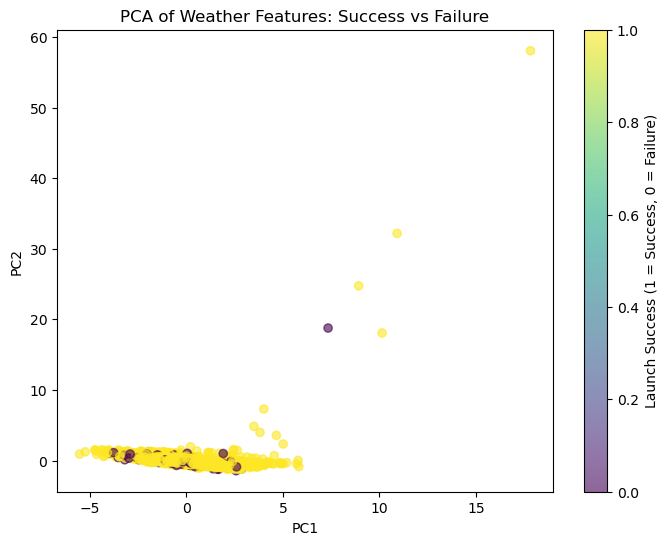

Top PC1 contributors:


HourlyDewPointTemperature    0.562071
HourlyDryBulbTemperature     0.509693
HourlyWetBulbTemperature     0.319411
weather_time_diff_minutes    0.298382
HourlyVisibility             0.286405
HourlyWindDirection          0.191086
HourlyPrecipitation          0.182164
short_duration_precip_max    0.182164
HourlyRelativeHumidity       0.133090
HourlyWindSpeed              0.118117
Name: PC1_loading, dtype: float64

Top PC2 contributors:


HourlyPrecipitation                    0.659590
short_duration_precip_max              0.659590
HourlyDryBulbTemperature               0.200011
HourlyDewPointTemperature              0.156005
HourlyWetBulbTemperature               0.120339
HourlyRelativeHumidity                 0.106506
present_weather_rain_flag              0.097772
cloud_cover_broken_or_overcast_flag    0.094629
weather_time_diff_minutes              0.090191
present_weather_thunder_flag           0.087611
Name: PC2_loading, dtype: float64

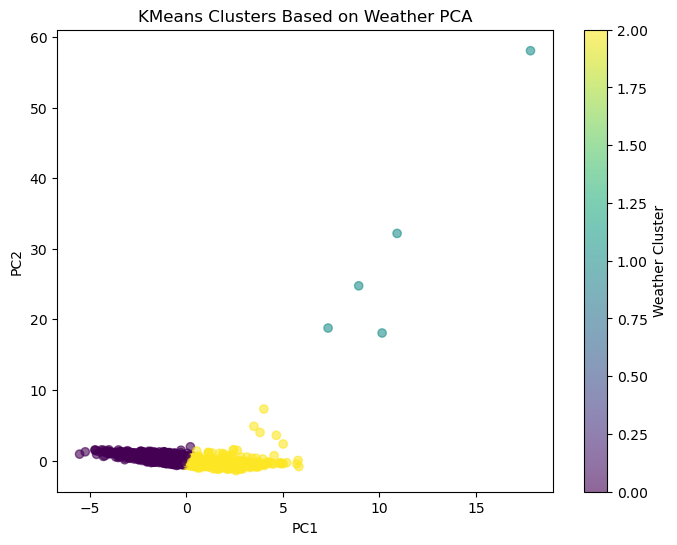

,count,success_rate
weather_cluster,,
0,1802,0.913430
1,5,0.800000
2,1560,0.905128


In [25]:
# PCA on weather features:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# use only matched weather data
df_pca = weather_df.copy()

X_weather = df_pca[weather_features].copy()

# impute missing weather values
imputer = SimpleImputer(strategy="median")
X_weather_imputed = imputer.fit_transform(X_weather)

# standardize weather variables
scaler = StandardScaler()
X_weather_scaled = scaler.fit_transform(X_weather_imputed)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_weather_scaled)

df_pca["PC1"] = X_pca[:, 0]
df_pca["PC2"] = X_pca[:, 1]

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("Total variance explained by PC1 and PC2:")
print(pca.explained_variance_ratio_.sum())



# PCA scatter plot: success vs failure
plt.figure(figsize=(8, 6))
plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    c=df_pca["is_success"],
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Weather Features: Success vs Failure")
plt.colorbar(label="Launch Success (1 = Success, 0 = Failure)")
plt.show()


# PCA loadings: interpret PCs
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1_loading", "PC2_loading"],
    index=weather_features
)

print("Top PC1 contributors:")
display(loadings["PC1_loading"].abs().sort_values(ascending=False).head(10))

print("Top PC2 contributors:")
display(loadings["PC2_loading"].abs().sort_values(ascending=False).head(10))



# KMeans clustering on PCA results
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_pca["weather_cluster"] = kmeans.fit_predict(df_pca[["PC1", "PC2"]])

plt.figure(figsize=(8, 6))
plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    c=df_pca["weather_cluster"],
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters Based on Weather PCA")
plt.colorbar(label="Weather Cluster")
plt.show()

# success rate by weather cluster
cluster_summary = df_pca.groupby("weather_cluster")["is_success"].agg(
    count="count",
    success_rate="mean"
)

display(cluster_summary)